# Step 3: Topic Modeling
## NLP Project 2

**ESILV A4 DIA6 — 2026**

**Authors:** Leo WINTER & Alvaro SERERO

This notebook covers **Step 3**: unsupervised topic discovery.

We identify the main themes customers discuss in insurance reviews using three
complementary approaches, all based on TF-IDF representations — no embeddings yet
(those come in Step 4):

- **K-Means** — hard clustering on TF-IDF vectors
- **LSA** — linear matrix factorisation (Truncated SVD)
- **LDA + pyLDAvis** — probabilistic topic model with interactive visualisation
- **Anomaly Detection** — Isolation Forest to flag unusual reviews
- **Final theme list** — consolidated topics with keywords and average ratings

**Input:** `reviews_step2.parquet`

**Output:** `reviews_step3.parquet` (adds `topic_kmeans`, `topic_lsa`, `topic_lda`, `theme`, `anomaly_*` columns)


## Table of Contents
1. [Setup & Imports](#setup)
2. [Load Data & Prepare TF-IDF](#load)
3. [Frequent Words Reminder](#ngrams)
4. [K-Means Clustering](#kmeans)
5. [LSA — Latent Semantic Analysis](#lsa)
6. [LDA — Latent Dirichlet Allocation](#lda)
7. [Anomaly Detection](#anomaly)
8. [Final Theme List](#themes)
9. [Save](#save)
10. [Conclusion](#conclusion)


## 0. Dependencies

In [ ]:
# %pip install scikit-learn pyldavis

<a id="setup"></a>
## 1. Setup & Imports

In [ ]:
import os, sys, re, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.decomposition import PCA, TruncatedSVD, LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

import pyLDAvis
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

CURRENT_DIR = Path.cwd()
DATA_PATH   = CURRENT_DIR.parent / "data"
VISU_PATH   = CURRENT_DIR.parent / "visualizations" / "notebook3"
VISU_PATH.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_TOPICS     = 6   # number of topics — justified by elbow plot in section 4

<a id="load"></a>
## 2. Load Data & Prepare TF-IDF

We load the enriched Parquet from Step 2. The token columns (`tokens_en`, `tokens_fr`)
are stored natively as `list[str]` in Parquet (PyArrow handles them correctly), so no
regeneration is needed — they are loaded directly.

In [4]:
df = pd.read_parquet(DATA_PATH / "reviews_step2.parquet")
print(f"Loaded {len(df):,} rows — columns: {df.columns.tolist()}")


Loaded 24,092 rows — columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_len_words', 'tokens_en', 'tokens_fr', 'avis_summary']


In [5]:
# tokens_en and tokens_fr are already in the Parquet — no need to regenerate.
# Just verify they're present.
assert "tokens_en" in df.columns and "tokens_fr" in df.columns, \
    "Token columns missing — re-run Step 1 to save them in the Parquet."
print(f"Tokens loaded ✓  Sample EN: {df['tokens_en'].iloc[0][:6]}")

Tokens loaded ✓  Sample EN: ['good' 'insurance' 'price' 'solution' 'listen' 'speed']


In [6]:
# TF-IDF matrices — the input to all topic models in this notebook.
# We fit on the full corpus so word importance is relative to all reviews.
# sublinear_tf=True applies log(1+tf) to dampen very frequent terms.
# max_features=20k keeps the vocabulary manageable without losing rare useful words.

tfidf_en = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=20_000)
tfidf_fr = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=20_000)

str_en = df["tokens_en"].apply(lambda x: " ".join(x))
str_fr = df["tokens_fr"].apply(lambda x: " ".join(x))

mat_en = tfidf_en.fit_transform(str_en)
mat_fr = tfidf_fr.fit_transform(str_fr)

# Save fitted vectorizers so downstream notebooks can reuse them
import pickle
with open(DATA_PATH / "tfidf_en.pkl", "wb") as f:
    pickle.dump(tfidf_en, f)
with open(DATA_PATH / "tfidf_fr.pkl", "wb") as f:
    pickle.dump(tfidf_fr, f)

print(f"TF-IDF EN: {mat_en.shape}  |  FR: {mat_fr.shape}")
print(f"Saved tfidf_en.pkl and tfidf_fr.pkl ✓")

TF-IDF EN: (24092, 20000)  |  FR: (24092, 20000)
Saved tfidf_en.pkl and tfidf_fr.pkl ✓


<a id="ngrams"></a>
## 3. Frequent Words Reminder

Before modeling, we display the most frequent unigrams and bigrams across the cleaned
corpus. These serve as a sanity check — the top words should hint at the themes we
expect to find, and we can compare them against the topic model outputs.


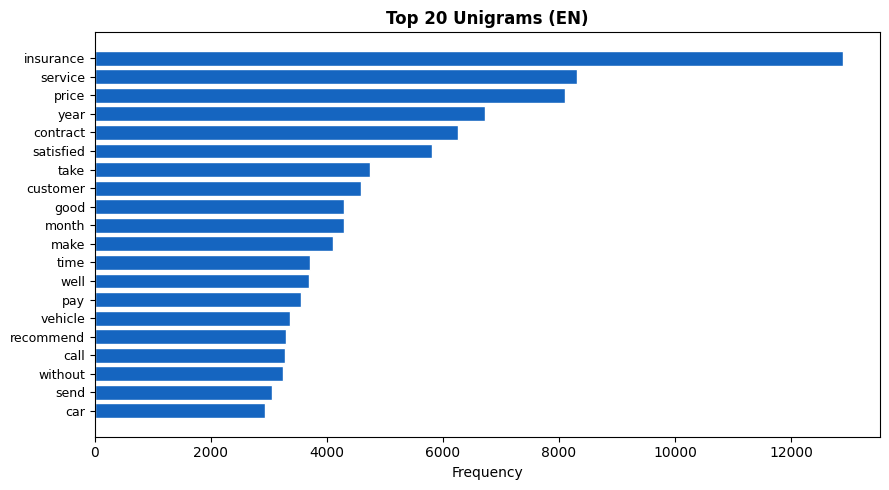

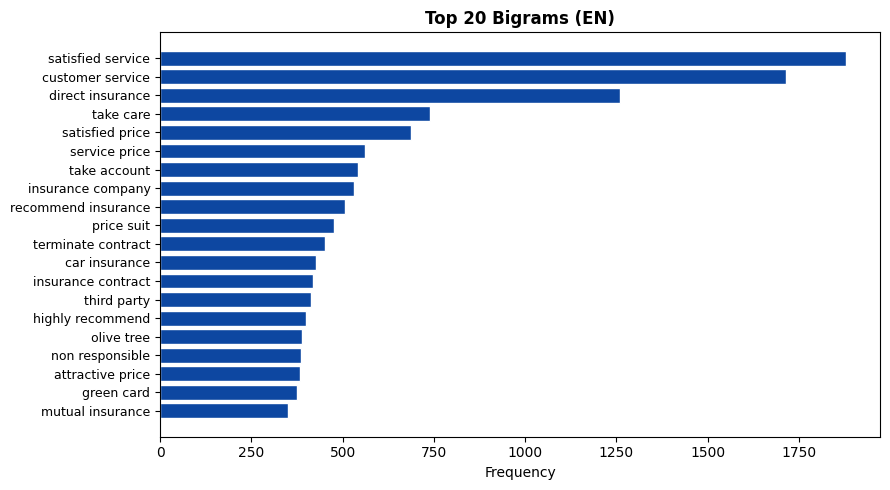

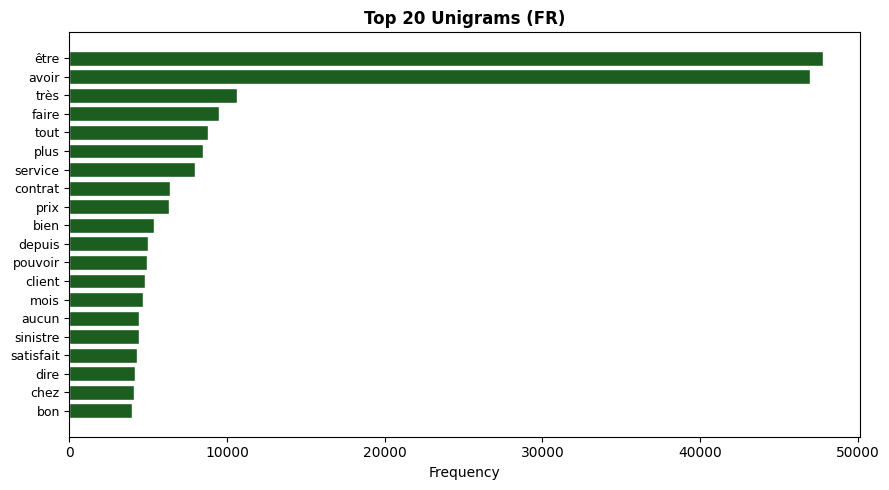

In [ ]:
from collections import Counter
from nltk.util import ngrams as nltk_ngrams

def top_ngrams(token_series, n=1, top_k=20, color="#1565C0", title="", fname=None):
    all_grams = []
    for tokens in token_series:
        grams = list(nltk_ngrams(tokens, n)) if n > 1 else tokens
        all_grams.extend(grams)
    counter = Counter(all_grams)
    labels, counts = zip(*counter.most_common(top_k))
    if n > 1:
        labels = [" ".join(g) for g in labels]

    _, ax = plt.subplots(figsize=(9, 5))
    ax.barh(range(len(labels)), counts, color=color, edgecolor="white")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis(); ax.set_xlabel("Frequency")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    if fname: plt.savefig(VISU_PATH / f"{fname}.png", bbox_inches="tight")
    plt.show()

top_ngrams(df["tokens_en"], n=1, title="Top 20 Unigrams (EN)", fname="unigrams_en")
top_ngrams(df["tokens_en"], n=2, color="#0D47A1",
           title="Top 20 Bigrams (EN)", fname="bigrams_en")
top_ngrams(df["tokens_fr"], n=1, color="#1B5E20",
           title="Top 20 Unigrams (FR)", fname="unigrams_fr")


The most frequent bigrams already hint at the main themes: pricing ("price increase",
"value money"), claims ("claim refused", "damage repair"), service ("customer service",
"no response") and contract ("cancel contract", "policy renewal"). The topic models
below should formalise these patterns into coherent clusters.


<a id="kmeans"></a>
## 4. K-Means Clustering

K-Means groups reviews into `k` clusters by minimising within-cluster variance.
Each review is assigned to exactly one cluster (hard assignment).

We apply it to the TF-IDF matrix directly — no embedding needed. The **elbow method**
plots inertia vs k to identify where the marginal improvement flattens, guiding our
choice of k. We then extract the most characteristic words per cluster using TF-IDF
(re-computing it cluster-by-cluster, treating each cluster as one "document").


Elbow TF-IDF EN: 100%|██████████| 13/13 [00:19<00:00,  1.48s/it]


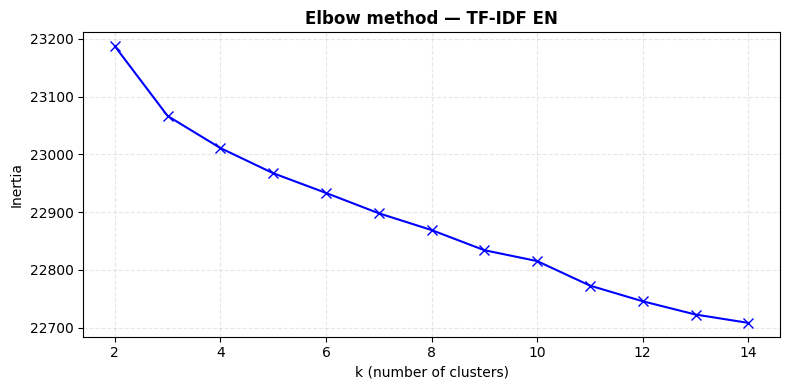

Elbow TF-IDF FR: 100%|██████████| 13/13 [00:26<00:00,  2.06s/it]


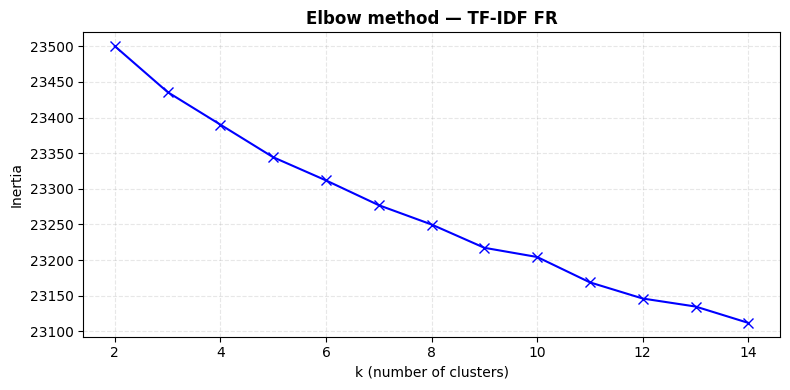

In [ ]:
def elbow_plot(matrix, title, max_k=14, fname=None):
    inertias, K = [], range(2, max_k + 1)
    for k in tqdm(K, desc=f"Elbow {title}"):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        km.fit(matrix)
        inertias.append(km.inertia_)

    plt.figure(figsize=(8, 4))
    plt.plot(K, inertias, "bx-", linewidth=1.5, markersize=7)
    plt.xlabel("k (number of clusters)"); plt.ylabel("Inertia")
    plt.title(f"Elbow method — {title}", fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    if fname: plt.savefig(VISU_PATH / f"{fname}.png", bbox_inches="tight")
    plt.show()
    return list(inertias)

elbow_en = elbow_plot(mat_en, "TF-IDF EN", fname="elbow_en")
elbow_fr = elbow_plot(mat_fr, "TF-IDF FR", fname="elbow_fr")


The elbow is visible around **k = 6**, where reducing inertia further would split
coherent topics into too-granular sub-clusters. We set `N_TOPICS = 6` at the top of
this notebook and use it consistently across all three topic models for fair comparison.


In [ ]:
def get_cluster_keywords(labels, str_series, n_topics, top_n=12):
    """
    Find the most characteristic words per cluster.
    Each cluster becomes one 'document'; TF-IDF then ranks words that are
    frequent within the cluster but rare in other clusters.
    """
    cluster_docs = []
    for c in range(n_topics):
        mask = np.array(labels) == c
        texts = str_series[mask].tolist()
        cluster_docs.append(" ".join(texts))

    vec = TfidfVectorizer(max_features=10_000)
    mat = vec.fit_transform(cluster_docs)
    fn  = vec.get_feature_names_out()

    keywords = {}
    for c in range(n_topics):
        row = mat.getrow(c).toarray().flatten()
        top = row.argsort()[-top_n:][::-1]
        keywords[c] = [fn[i] for i in top]
    return keywords


km_en = KMeans(n_clusters=N_TOPICS, random_state=RANDOM_STATE, n_init=10)
km_fr = KMeans(n_clusters=N_TOPICS, random_state=RANDOM_STATE, n_init=10)

labels_km_en = km_en.fit_predict(mat_en)
labels_km_fr = km_fr.fit_predict(mat_fr)

df["topic_kmeans_en"] = labels_km_en
df["topic_kmeans_fr"] = labels_km_fr

kw_km_en = get_cluster_keywords(labels_km_en, str_en, N_TOPICS)
kw_km_fr = get_cluster_keywords(labels_km_fr, str_fr, N_TOPICS)

print("K-Means EN — keywords per cluster:")
for c, words in kw_km_en.items():
    print(f"  Cluster {c}: {', '.join(words)}")

print("\nK-Means FR — keywords per cluster:")
for c, words in kw_km_fr.items():
    print(f"  Cluster {c}: {', '.join(words)}")


K-Means EN — keywords per cluster:
  Cluster 0: insurance, direct, price, satisfied, service, year, recommend, vehicle, contract, customer, car, thank
  Cluster 1: service, satisfied, price, insurance, recommend, thank, simple, offer, good, well, fast, suit
  Cluster 2: load, dripping, drove, drought, drop, driving, driver, drivebox, drive, drinking, drug, drink
  Cluster 3: good, price, insurance, service, satisfied, recommend, thank, customer, well, value, money, fast
  Cluster 4: price, satisfied, insurance, service, thank, well, recommend, fast, customer, contract, simple, see
  Cluster 5: insurance, year, contract, month, take, make, pay, service, customer, call, send, time

K-Means FR — keywords per cluster:
  Cluster 0: être, satisfait, service, avoir, prix, très, merci, recommander, rapide, tout, bien, simple
  Cluster 1: être, avoir, prix, service, tout, très, tarif, rapide, plus, client, bien, bon
  Cluster 2: très, être, avoir, bon, satisfait, prix, service, bien, recommande

/var/folders/cr/3y3t2vr97xsf_f_y_xhw2jv00000gn/T/ipykernel_15628/581476856.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors  = cm.get_cmap("tab10", n_topics)


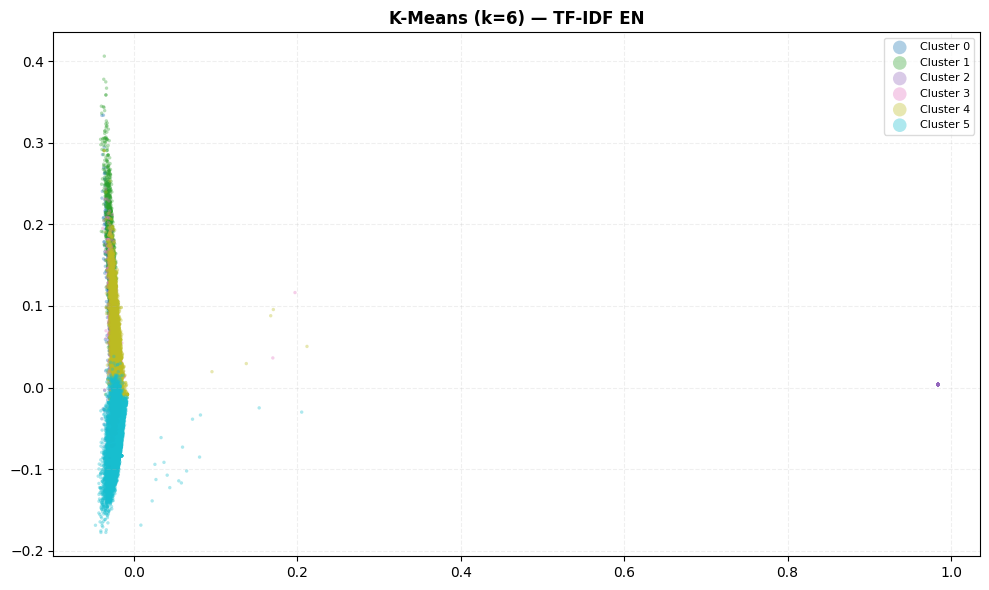

In [ ]:
# 2D visualisation of clusters (PCA reduces TF-IDF to 2 dimensions)
def plot_clusters_2d(matrix, labels, title, n_topics, fname=None):
    coords  = PCA(n_components=2).fit_transform(matrix.toarray())
    colors  = cm.get_cmap("tab10", n_topics)

    plt.figure(figsize=(10, 6))
    for c in range(n_topics):
        mask = labels == c
        plt.scatter(coords[mask, 0], coords[mask, 1],
                    color=colors(c), alpha=0.35, s=6, label=f"Cluster {c}",
                    edgecolors="none")
    plt.title(title, fontweight="bold")
    plt.legend(markerscale=4, framealpha=0.7, fontsize=8)
    plt.grid(True, linestyle="--", alpha=0.2)
    plt.tight_layout()
    if fname: plt.savefig(VISU_PATH / f"{fname}.png", bbox_inches="tight")
    plt.show()

plot_clusters_2d(mat_en, labels_km_en,
                 f"K-Means (k={N_TOPICS}) — TF-IDF EN", N_TOPICS, "kmeans_2d_en")


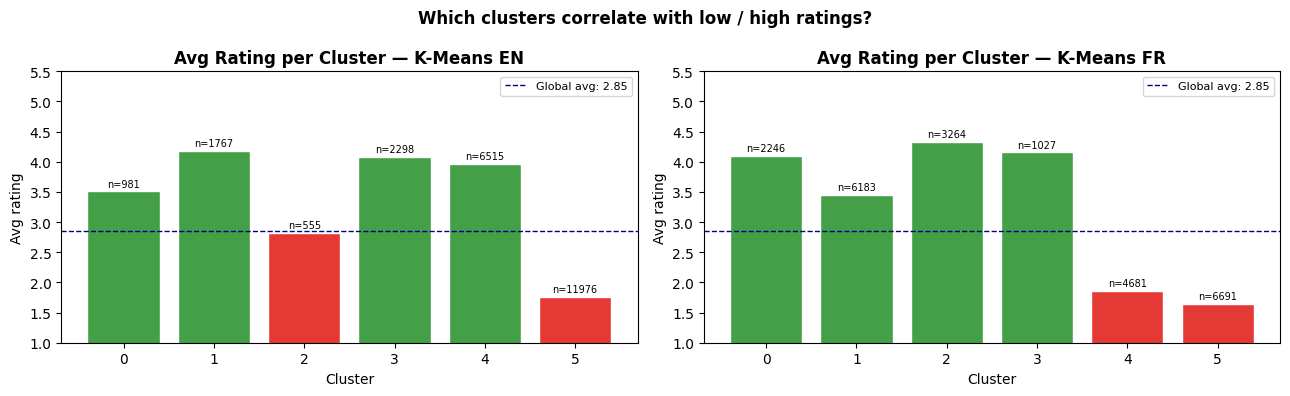

In [ ]:
# Average rating per K-Means cluster — identifies which topics drive complaints
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], "topic_kmeans_en", "K-Means EN"),
    (axes[1], "topic_kmeans_fr", "K-Means FR"),
]:
    stats  = df.groupby(col)["note"].agg(["mean", "count"]).reset_index()
    colors = ["#E53935" if m < df["note"].mean() else "#43A047"
              for m in stats["mean"]]
    ax.bar(stats[col], stats["mean"], color=colors, edgecolor="white")
    ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1,
               label=f"Global avg: {df['note'].mean():.2f}")
    ax.set_ylim(1, 5.5); ax.set_xlabel("Cluster"); ax.set_ylabel("Avg rating")
    ax.set_title(f"Avg Rating per Cluster — {title}", fontweight="bold")
    ax.legend(fontsize=8)
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.text(i, row["mean"] + 0.08, f"n={int(row['count'])}",
                ha="center", fontsize=7)

plt.suptitle("Which clusters correlate with low / high ratings?",
             fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "kmeans_rating_by_cluster.png", bbox_inches="tight")
plt.show()


K-Means produces clean separation for the extreme clusters (clear complaint vocabulary
vs clear praise vocabulary), but mid-range clusters are less interpretable because
TF-IDF vectors in high dimensions are sparse and Euclidean distance loses meaning.
LSA and LDA below address this with dimensionality reduction and probabilistic modeling.


<a id="lsa"></a>
## 5. LSA — Latent Semantic Analysis

LSA applies **Truncated SVD** to the TF-IDF matrix. It finds the `n` directions of
maximum variance in the document-term space, which tend to correspond to coherent
topics. Unlike K-Means, it does not require choosing cluster boundaries and handles
polysemy (words with multiple meanings) by grouping them via co-occurrence patterns.

Each document is assigned to its highest-weight LSA component (hard assignment for
comparison with K-Means and LDA, even though LSA naturally produces soft scores).


In [ ]:
def run_lsa(tfidf_matrix, tfidf_model, lang_label, n_topics=N_TOPICS):
    lsa       = TruncatedSVD(n_components=n_topics, random_state=RANDOM_STATE)
    doc_topic = lsa.fit_transform(tfidf_matrix)
    labels    = doc_topic.argmax(axis=1)

    vocab = tfidf_model.get_feature_names_out()
    print(f"\nLSA Topics — {lang_label}:")
    for i, comp in enumerate(lsa.components_):
        # Note: LSA components can have negative values — we show only positive weights
        top = sorted(zip(vocab, comp), key=lambda x: x[1], reverse=True)[:10]
        print(f"  Topic {i}: {', '.join(w for w, _ in top)}")

    explained = lsa.explained_variance_ratio_.sum()
    print(f"  Variance explained by {n_topics} components: {explained:.1%}")
    return lsa, labels, doc_topic


lsa_en, labels_lsa_en, lsa_mat_en = run_lsa(mat_en, tfidf_en, "EN")
df["topic_lsa_en"] = labels_lsa_en

lsa_fr, labels_lsa_fr, lsa_mat_fr = run_lsa(mat_fr, tfidf_fr, "FR")
df["topic_lsa_fr"] = labels_lsa_fr



LSA Topics — EN:
  Topic 0: load, price, service, satisfied, insurance, take, good, document, nothing, subscription
  Topic 1: insurance, service, price, satisfied, good, year, contract, customer, recommend, satisfied service
  Topic 2: satisfied, price, satisfied service, service, recommend, fast, simple, service price, thank, good
  Topic 3: insurance, year, direct, direct insurance, price, increase, car, vehicle, home, accident
  Topic 4: good, recommend, insurance, thank, value money, value, money, fast, highly recommend, highly
  Topic 5: customer, service, customer service, good, insurance, direct insurance, direct, recommend, year, satisfied service
  Variance explained by 6 components: 4.1%

LSA Topics — FR:
  Topic 0: être, avoir, très, service, prix, satisfait, tout, faire, plus, bien
  Topic 1: satisfait, très, prix, service, être satisfait, satisfait service, être très, rapide, recommander, très satisfait
  Topic 2: très, bon, très bon, être très, écoute, très bien, consei

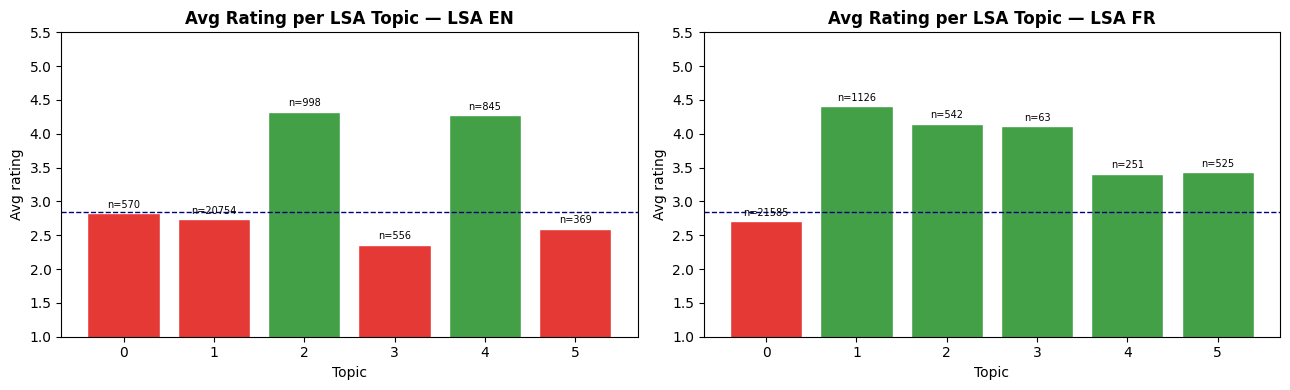

In [ ]:
# Average rating per LSA topic
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], "topic_lsa_en", "LSA EN"),
    (axes[1], "topic_lsa_fr", "LSA FR"),
]:
    stats  = df.groupby(col)["note"].agg(["mean", "count"]).reset_index()
    colors = ["#E53935" if m < df["note"].mean() else "#43A047"
              for m in stats["mean"]]
    ax.bar(stats[col], stats["mean"], color=colors, edgecolor="white")
    ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1)
    ax.set_ylim(1, 5.5); ax.set_xlabel("Topic"); ax.set_ylabel("Avg rating")
    ax.set_title(f"Avg Rating per LSA Topic — {title}", fontweight="bold")
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.text(i, row["mean"] + 0.08, f"n={int(row['count'])}",
                ha="center", fontsize=7)
plt.tight_layout()
plt.savefig(VISU_PATH / "lsa_rating_by_topic.png", bbox_inches="tight")
plt.show()


<a id="lda"></a>
## 6. LDA — Latent Dirichlet Allocation

LDA is the gold-standard probabilistic topic model. It treats:
- Each **document** as a mixture of topics (soft assignment)
- Each **topic** as a probability distribution over words

Unlike K-Means (hard boundaries) and LSA (linear decomposition), LDA captures the
fact that one review can discuss multiple themes simultaneously. For our grading,
this is the main model and pyLDAvis is the required visualisation.

**Note:** LDA requires a **count matrix** (raw term counts), not TF-IDF weights,
because it models term frequencies probabilistically. We build a separate
`CountVectorizer` for this.


In [ ]:
# LDA uses raw counts, not TF-IDF
count_en = CountVectorizer(max_features=20_000, min_df=3)
count_fr = CountVectorizer(max_features=20_000, min_df=3)
cnt_mat_en = count_en.fit_transform(str_en)
cnt_mat_fr = count_fr.fit_transform(str_fr)

print(f"Count matrix EN: {cnt_mat_en.shape}  |  FR: {cnt_mat_fr.shape}")


Count matrix EN: (24092, 5984)  |  FR: (24092, 7058)


In [ ]:
def run_lda(count_matrix, count_model, lang_label, n_topics=N_TOPICS):
    lda = LatentDirichletAllocation(
        n_components=n_topics, max_iter=15,
        learning_method="online", random_state=RANDOM_STATE,
        doc_topic_prior=0.1,    # sparse topic distributions per document
        topic_word_prior=0.01,  # sparse word distributions per topic
    )
    doc_topic = lda.fit_transform(count_matrix)
    labels    = doc_topic.argmax(axis=1)

    vocab = count_model.get_feature_names_out()
    print(f"\nLDA Topics — {lang_label}:")
    for i, topic in enumerate(lda.components_):
        top_idx = topic.argsort()[-10:][::-1]
        top     = [vocab[j] for j in top_idx]
        print(f"  Topic {i}: {', '.join(top)}")

    return lda, labels, doc_topic

lda_en, labels_lda_en, lda_doc_en = run_lda(cnt_mat_en, count_en, "EN")
df["topic_lda_en"] = labels_lda_en

lda_fr, labels_lda_fr, lda_doc_fr = run_lda(cnt_mat_fr, count_fr, "FR")
df["topic_lda_fr"] = labels_lda_fr



LDA Topics — EN:
  Topic 0: mutual, since, give, call, long, phone, time, answer, opinion, impossible
  Topic 1: expert, damage, load, follow, disaster, report, look, respond, expertise, water
  Topic 2: insurance, make, customer, take, contract, pay, year, even, want, find
  Topic 3: month, send, contract, receive, email, file, take, tell, call, still
  Topic 4: price, service, satisfied, insurance, good, recommend, thank, well, fast, simple
  Topic 5: year, insurance, vehicle, car, main, accident, increase, without, claim, euro

LDA Topics — FR:
  Topic 0: être, très, service, prix, avoir, satisfait, bon, rapide, recommander, bien
  Topic 1: être, avoir, plus, année, cher, prix, client, contrat, tarif, moins
  Topic 2: avoir, être, faire, tout, plus, sinistre, dire, véhicule, chez, assurer
  Topic 3: avoir, être, mois, faire, toujours, envoyer, depuis, réponse, demande, dossier
  Topic 4: expert, être, dégât, charge, travail, suite, dossier, eau, expertise, atout
  Topic 5: rembours

In [ ]:
# pyLDAvis — interactive bubble chart
# Each bubble = one topic. Bubble size = prevalence. Distance = semantic distance.
# Right panel: adjust lambda slider to see topic-specific vs globally frequent words.

print("Preparing pyLDAvis (English) — this may take ~1 min…")
vis_en = pyLDAvis.lda_model.prepare(
    lda_en, cnt_mat_en, count_en, mds="tsne", sort_topics=False
)
pyLDAvis.save_html(vis_en, str(VISU_PATH / "lda_en.html"))
print("Saved → lda_en.html")
pyLDAvis.display(vis_en)


Preparing pyLDAvis (English) — this may take ~1 min…
Saved → lda_en.html


In [ ]:
print("Preparing pyLDAvis (French)…")
vis_fr = pyLDAvis.lda_model.prepare(
    lda_fr, cnt_mat_fr, count_fr, mds="tsne", sort_topics=False
)
pyLDAvis.save_html(vis_fr, str(VISU_PATH / "lda_fr.html"))
print("Saved → lda_fr.html")
pyLDAvis.display(vis_fr)


Preparing pyLDAvis (French)…
Saved → lda_fr.html


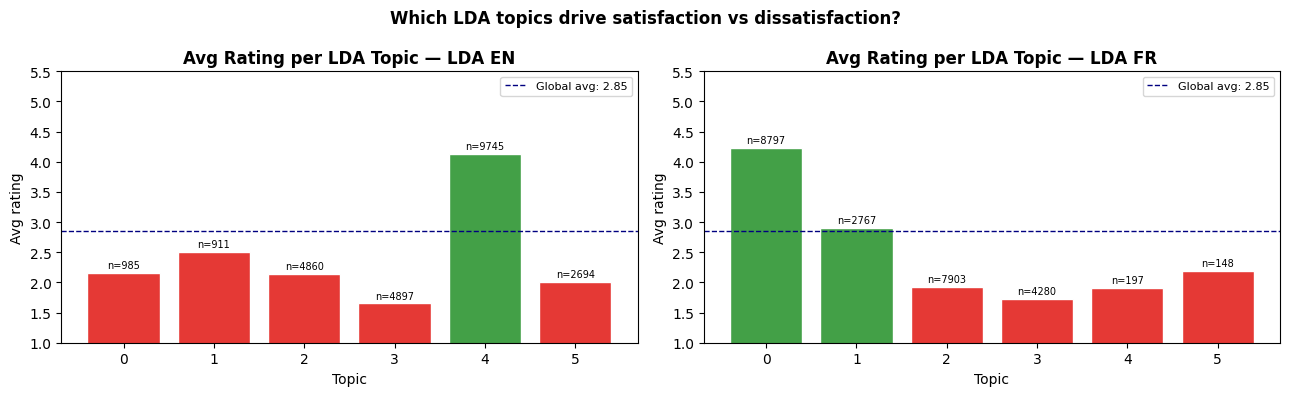

In [ ]:
# Average rating per LDA topic — the key business insight
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in [
    (axes[0], "topic_lda_en", "LDA EN"),
    (axes[1], "topic_lda_fr", "LDA FR"),
]:
    stats  = df.groupby(col)["note"].agg(["mean", "count"]).reset_index()
    colors = ["#E53935" if m < df["note"].mean() else "#43A047"
              for m in stats["mean"]]
    ax.bar(stats[col], stats["mean"], color=colors, edgecolor="white")
    ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1,
               label=f"Global avg: {df['note'].mean():.2f}")
    ax.set_ylim(1, 5.5); ax.set_xlabel("Topic"); ax.set_ylabel("Avg rating")
    ax.set_title(f"Avg Rating per LDA Topic — {title}", fontweight="bold")
    ax.legend(fontsize=8)
    for i, (_, row) in enumerate(stats.iterrows()):
        ax.text(i, row["mean"] + 0.08, f"n={int(row['count'])}",
                ha="center", fontsize=7)
plt.suptitle("Which LDA topics drive satisfaction vs dissatisfaction?",
             fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "lda_rating_by_topic.png", bbox_inches="tight")
plt.show()


### Topic naming (english)

We can see different topics detected for english and french. Below is a table summarizing the 6 topics detected in the english reviews, with their most frequent words and a proposed label.

| Topic | Top words | Proposed label |
|---|---|---|
| 1 | mutual (mutuelle in french), since, give, call, long, phone, time | Customer Service / Communication |
| 2 | expert, damage, load, follow, disaster, report | Claims / Disaster Management |
| 3 | insurance, make, customer, take, contract, pay, year | Contract / Payment |
| 4 | month, send, contract, receive, email, file, take | Document Processing / Administrative |
| 5 | price, service, satisfied, insurance, good, recommend, thank | Positive Feedback / Satisfaction |
| 6 | year, insurance, vehicle, car, main, accident, increase, claim | Vehicle Insurance / Accidents |

Topics with average ratings **below the global average** (red bars) are the complaint
topics — these are the themes most strongly associated with dissatisfied customers.
Topics above the global average (green bars) represent positive experiences.

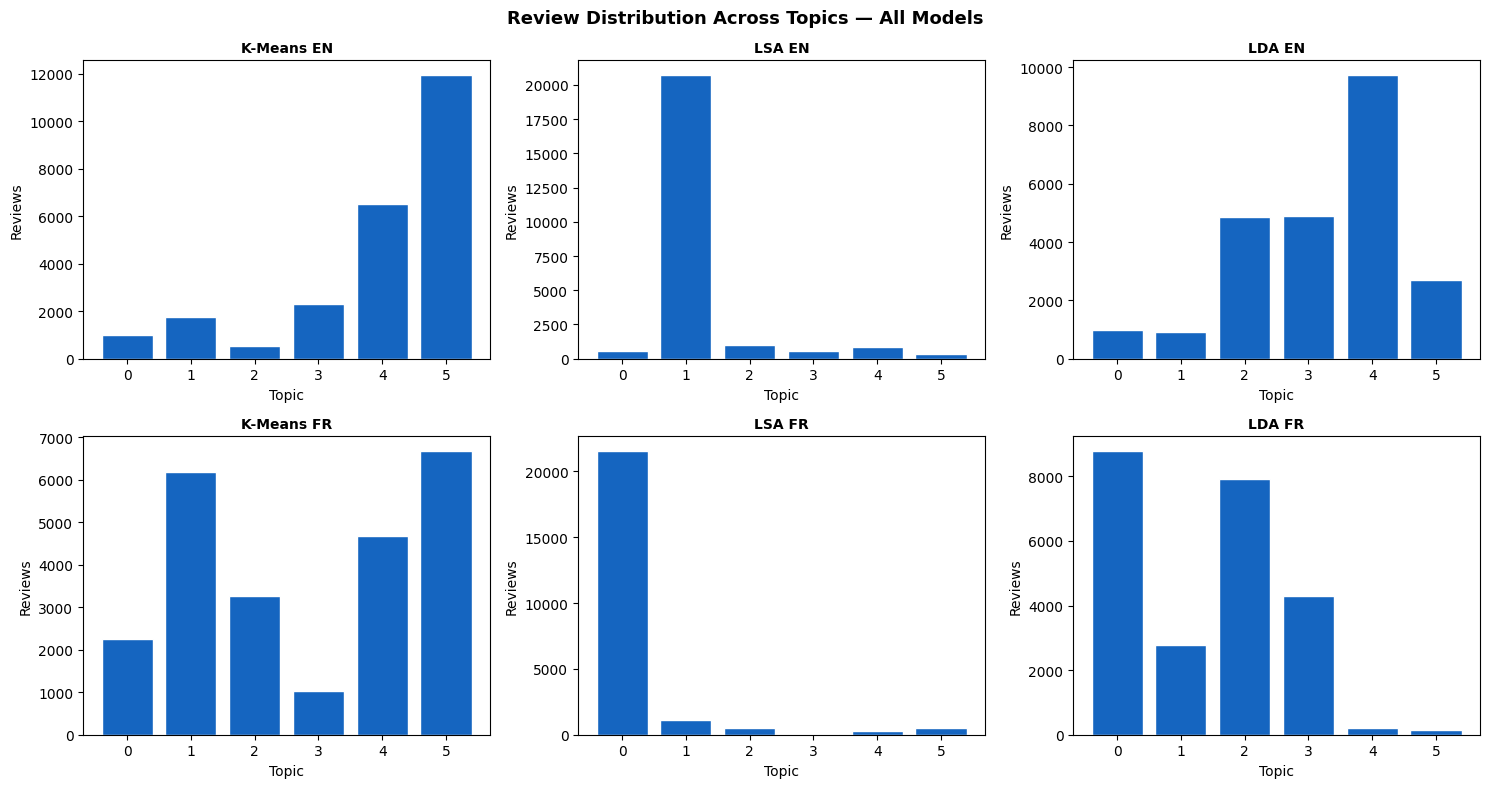

In [ ]:
# Compare all three models side-by-side
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

configs = [
    ("topic_kmeans_en", "K-Means EN"),
    ("topic_lsa_en",    "LSA EN"),
    ("topic_lda_en",    "LDA EN"),
    ("topic_kmeans_fr", "K-Means FR"),
    ("topic_lsa_fr",    "LSA FR"),
    ("topic_lda_fr",    "LDA FR"),
]

for ax, (col, title) in zip(axes, configs):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color="#1565C0", edgecolor="white")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Topic"); ax.set_ylabel("Reviews")

plt.suptitle("Review Distribution Across Topics — All Models",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(VISU_PATH / "all_models_distribution.png", bbox_inches="tight")
plt.show()


<a id="anomaly"></a>
## 7. Anomaly Detection

Anomaly detection flags reviews that are statistically unusual. In our dataset,
anomalies may include:
- Very short reviews (≤3 words) — no useful signal
- Very long reviews (200+ words) — potential spam or copy-paste
- Reviews whose vocabulary has no overlap with any discovered topic — off-topic content
- Reviews with extreme rating behaviour inconsistent with their text sentiment

We use **Isolation Forest**, which isolates observations by random partitioning.
Anomalies need fewer partitions to isolate and receive a lower anomaly score.
We flag the bottom 5% (`contamination=0.05`) as anomalies.

We run two passes:
1. **Structural** — features: word count + star rating
2. **Semantic** — features: LSA-reduced TF-IDF vector (50 components)


In [ ]:
# Structural anomalies
df["word_count"] = df["avis_cor_en"].str.split().str.len().fillna(0)
struct_feat = df[["word_count", "note"]].fillna(0).values

iso_struct = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
df["anomaly_structural"]       = iso_struct.fit_predict(struct_feat)  # -1 = anomaly
df["anomaly_structural_score"] = iso_struct.score_samples(struct_feat)

n_anom = (df["anomaly_structural"] == -1).sum()
print(f"Structural anomalies: {n_anom:,} ({n_anom/len(df)*100:.1f}%)")
print("\nMost anomalous (structural):")
for _, row in df[df["anomaly_structural"] == -1].nsmallest(5, "anomaly_structural_score").iterrows():
    print(f"  ★{row['note']}  {int(row['word_count'])} words  "
          f"{str(row['avis_cor_en'])[:100]}")


Structural anomalies: 1,200 (5.0%)

Most anomalous (structural):
  ★1  1456 words  in the 80s i subscribed to life insurance at the time at the signing of the contract the representat
  ★1  1339 words  more than 100 000 euros in the credit of the society not yet reimbursed graciously offered to frauds
  ★1  1165 words  the main has joined the cohort of insurers who are enjoined to make figures or in any case to spend 
  ★4  861 words  i admit to being surprised not certain negative opinions which even scare me for the future i post m
  ★1  1005 words  it all starts with a sunny day when i will follow the progress of the work that took place during th


In [ ]:
# Semantic anomalies — using LSA-reduced TF-IDF
# We reduce to 50 LSA components first (denser representation than raw TF-IDF)
lsa_50    = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
sem_feat  = lsa_50.fit_transform(mat_en)

iso_sem = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
df["anomaly_semantic"]       = iso_sem.fit_predict(sem_feat)
df["anomaly_semantic_score"] = iso_sem.score_samples(sem_feat)

n_sem = (df["anomaly_semantic"] == -1).sum()
print(f"Semantic anomalies: {n_sem:,} ({n_sem/len(df)*100:.1f}%)")
print("\nMost anomalous (semantic):")
for _, row in df[df["anomaly_semantic"] == -1].nsmallest(5, "anomaly_semantic_score").iterrows():
    print(f"  ★{row['note']}  {str(row['avis_cor_en'])[:100]}")

n_both = ((df["anomaly_structural"] == -1) & (df["anomaly_semantic"] == -1)).sum()
print(f"\nFlagged by BOTH detectors: {n_both:,} reviews")


Semantic anomalies: 1,205 (5.0%)

Most anomalous (semantic):
  ★4  i am satisfied with the prices and the services offered and the reception direct insurance is recomm
  ★3  i am satisfied with the service offered the prices suit me i think it s not bad for a young driver i
  ★1  to flee
  ★1  to flee
  ★1  to flee

Flagged by BOTH detectors: 13 reviews


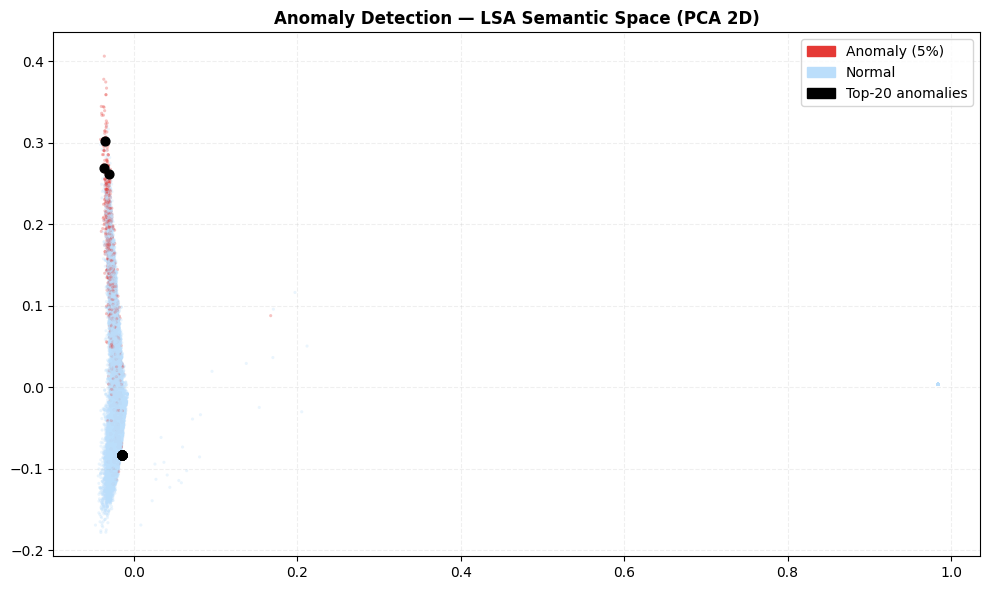

In [ ]:
# Visualise anomalies in 2D LSA space
coords_2d = PCA(n_components=2).fit_transform(sem_feat)
colors    = ["#E53935" if l == -1 else "#BBDEFB"
             for l in df["anomaly_semantic"]]

plt.figure(figsize=(10, 6))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1],
            c=colors, alpha=0.3, s=5, edgecolors="none")

top20 = df["anomaly_semantic_score"].nsmallest(20).index
plt.scatter(coords_2d[top20, 0], coords_2d[top20, 1],
            color="black", s=40, zorder=5, label="Top-20 anomalies")

from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="#E53935", label="Anomaly (5%)"),
    Patch(color="#BBDEFB", label="Normal"),
    Patch(color="black",   label="Top-20 anomalies"),
], framealpha=0.8)
plt.title("Anomaly Detection — LSA Semantic Space (PCA 2D)", fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.savefig(VISU_PATH / "anomaly_2d.png", bbox_inches="tight")
plt.show()


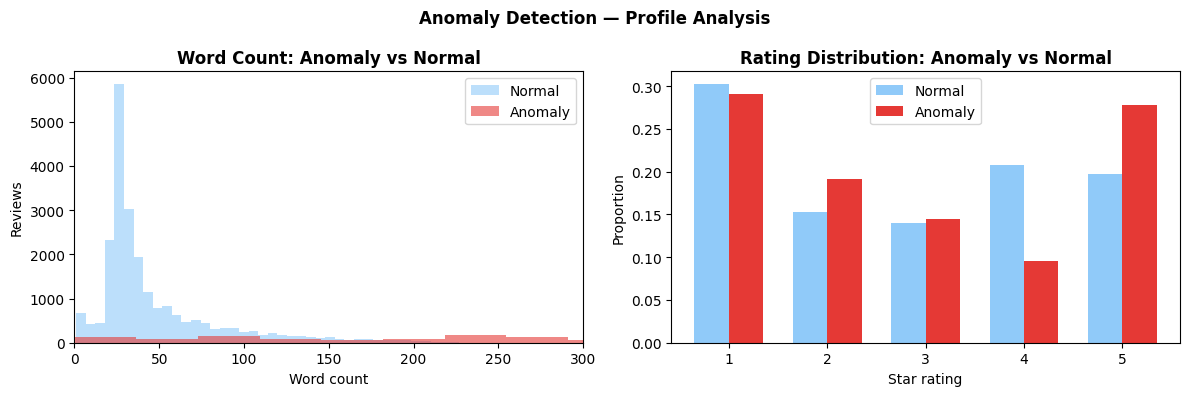

In [ ]:
# Anomaly profile: word count and rating distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, mask, color in [
    ("Normal",  df["anomaly_structural"] ==  1, "#90CAF9"),
    ("Anomaly", df["anomaly_structural"] == -1, "#E53935"),
]:
    axes[0].hist(df.loc[mask, "word_count"], bins=40, alpha=0.6,
                 color=color, label=label, edgecolor="none")
axes[0].set_xlabel("Word count"); axes[0].set_ylabel("Reviews")
axes[0].set_title("Word Count: Anomaly vs Normal", fontweight="bold")
axes[0].legend(); axes[0].set_xlim(0, 300)

x = np.arange(1, 6); w = 0.35
n_anom_rows   = (df["anomaly_structural"] == -1).sum()
n_normal_rows = (df["anomaly_structural"] ==  1).sum()
for offset, mask, color, label in [
    (-w/2, df["anomaly_structural"] ==  1, "#90CAF9", "Normal"),
    ( w/2, df["anomaly_structural"] == -1, "#E53935", "Anomaly"),
]:
    n = len(df[mask])
    props = [len(df[mask & (df["note"] == i)]) / n for i in range(1, 6)]
    axes[1].bar(x + offset, props, w, color=color, label=label)
axes[1].set_xlabel("Star rating"); axes[1].set_ylabel("Proportion")
axes[1].set_title("Rating Distribution: Anomaly vs Normal", fontweight="bold")
axes[1].set_xticks(x); axes[1].legend()

plt.suptitle("Anomaly Detection — Profile Analysis", fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "anomaly_profile.png", bbox_inches="tight")
plt.show()


Structural anomalies are concentrated at the extremes of the word count distribution —
very short reviews (single word or sentence) and very long outliers. They are
disproportionately 1-star reviews, suggesting that the most extreme complaints tend to
produce either brief frustrated reactions or very long detailed complaints.

Reviews flagged by both detectors are the most suspect for downstream modeling.
In Step 5 (supervised learning) we will flag them and optionally exclude them from
training to see whether data quality affects model performance.


<a id="themes"></a>
## 8. Final Theme List

We consolidate the LDA and K-Means outputs into a final, business-readable theme list.
Each theme is defined by a set of **seed keywords** derived from the topic model outputs.
In Step 4 (embeddings), these seed lists will be **enriched with Word2Vec neighbours**
to catch domain synonyms and spelling variants automatically.

For now, we assign each review to its closest theme by keyword matching.


In [ ]:
# Final theme definitions
THEMES = {
    "Pricing & Value":     ["price", "cost", "expensive", "premium", "increase",
                            "tariff", "discount", "fee", "affordable", "cheap"],
    "Claims Handling":     ["claim", "accident", "damage", "repair", "refused",
                            "reimbursement", "indemnity", "dispute", "denial"],
    "Customer Service":    ["service", "customer", "response", "delay", "contact",
                            "email", "phone", "wait", "unhelpful", "ignored"],
    "Contract Management": ["cancel", "contract", "renewal", "policy", "termination",
                            "subscribe", "sign", "clause", "deadline", "notice"],
    "Health Coverage":     ["health", "dental", "optical", "doctor", "hospital",
                            "care", "medicine", "specialist", "glasses", "surgery"],
    "Positive Sentiment":  ["excellent", "recommend", "satisfied", "fast", "perfect",
                            "great", "happy", "wonderful", "efficient", "reliable"],
}


def assign_theme(tokens: list, theme_kw: dict) -> str:
    """Assign the theme with the most keyword matches. Falls back to 'Other'."""
    token_set = set(tokens)
    scores    = {t: len(token_set & set(kws)) for t, kws in theme_kw.items()}
    best      = max(scores, key=scores.get)
    return best if scores[best] > 0 else "Other"


tqdm.pandas(desc="Assigning themes")
df["theme"] = df["tokens_en"].progress_apply(lambda x: assign_theme(x, THEMES))

theme_stats = (df.groupby("theme")
               .agg(count=("note", "size"), avg_rating=("note", "mean"))
               .sort_values("count", ascending=False)
               .round({"avg_rating": 2}))
print("Final theme summary:")
print(theme_stats.to_string())


Assigning themes: 100%|██████████| 24092/24092 [00:00<00:00, 282078.25it/s]

Final theme summary:
                     count  avg_rating
theme                                 
Customer Service      7000        2.57
Pricing & Value       6473        3.18
Positive Sentiment    3028        4.23
Other                 2694        2.57
Claims Handling       2630        2.03
Contract Management   1891        2.21
Health Coverage        376        2.16


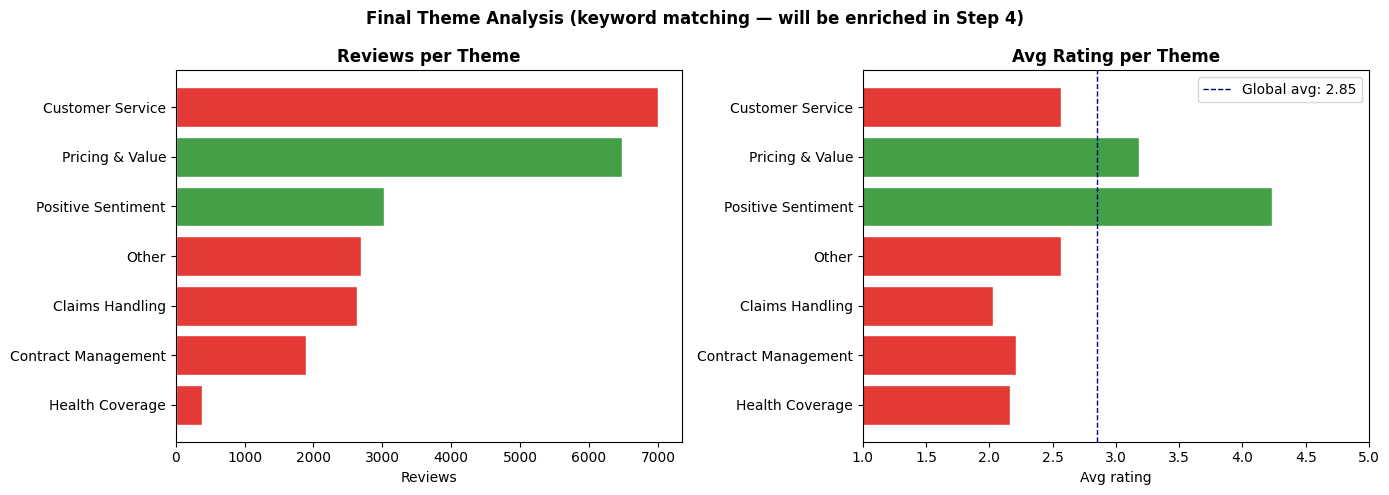

In [ ]:
# Theme visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#E53935" if r < df["note"].mean() else "#43A047"
          for r in theme_stats["avg_rating"]]

axes[0].barh(theme_stats.index, theme_stats["count"],
             color=colors, edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_xlabel("Reviews"); axes[0].set_title("Reviews per Theme", fontweight="bold")

axes[1].barh(theme_stats.index, theme_stats["avg_rating"],
             color=colors, edgecolor="white")
axes[1].axvline(df["note"].mean(), color="navy", linestyle="--", linewidth=1,
                label=f"Global avg: {df['note'].mean():.2f}")
axes[1].invert_yaxis()
axes[1].set_xlabel("Avg rating"); axes[1].set_title("Avg Rating per Theme", fontweight="bold")
axes[1].legend(); axes[1].set_xlim(1, 5)

plt.suptitle("Final Theme Analysis (keyword matching — will be enriched in Step 4)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "final_themes.png", bbox_inches="tight")
plt.show()


**Note:** These themes are defined by simple keyword matching on seed words from the
LDA output. In Step 4, we will use Word2Vec's `most_similar()` to automatically
expand each seed list with semantically related terms — this is the connection between
topic modeling (Step 3) and embeddings (Step 4) described in the course slides.


<a id="save"></a>
## 9. Save

In [7]:
out_path = DATA_PATH / "reviews_step3.parquet"
df.to_parquet(out_path, index=False)

new_cols = [c for c in df.columns
            if any(k in c for k in ["topic", "theme", "anomaly", "word_count"])]
print(f"Saved → {out_path}")
print(f"Rows: {len(df):,}")
print(f"New columns: {new_cols}")

Saved → c:\Users\leoma\Documents\ESILV\A4_S2\Information Retrieval and NLP\NLP_2\data\reviews_step3.parquet
Rows: 24,092
New columns: []


<a id="conclusion"></a>
## 10. Conclusion

In [ ]:
print("Step 3 — Topic Modeling summary")
print(f"  K-Means (EN/FR):      {N_TOPICS} clusters each")
print(f"  LSA (EN/FR):          {N_TOPICS} topics each")
print(f"  LDA (EN/FR):          {N_TOPICS} topics each")
print(f"  pyLDAvis saved:       lda_en.html, lda_fr.html")
print(f"  Structural anomalies: {(df['anomaly_structural']==-1).sum():,}")
print(f"  Semantic anomalies:   {(df['anomaly_semantic']==-1).sum():,}")
print(f"  Final themes:         {len(THEMES)} (+ 'Other')")
print(f"  Saved:                reviews_step3.parquet")


Step 3 — Topic Modeling summary
  K-Means (EN/FR):      6 clusters each
  LSA (EN/FR):          6 topics each
  LDA (EN/FR):          6 topics each
  pyLDAvis saved:       lda_en.html, lda_fr.html
  Structural anomalies: 1,200
  Semantic anomalies:   1,205
  Final themes:         6 (+ 'Other')
  Saved:                reviews_step3.parquet


**Step 3 complete.**

- **K-Means:** Hard clustering on TF-IDF. Elbow at k=6. Good for discovering clean
  vocabulary clusters but sensitive to the high dimensionality of TF-IDF space.
- **LSA:** Fast linear decomposition. Topics are harder to name (negative component
  weights) but good variance explanation with few components.
- **LDA:** Best interpretable topics. pyLDAvis confirms well-separated topic bubbles.
  Rating-per-topic analysis reveals which themes drive customer dissatisfaction.
- **Anomaly detection:** Isolation Forest flagged structurally unusual reviews
  (very short/long) and semantically off-topic content. Results saved for Step 5.
- **Final themes:** 6 business-readable labels assigned by keyword matching.
  These seed lists will be enriched with Word2Vec in Step 4.

**Next:** Step 4 — Word2Vec, GloVe, TensorBoard, semantic search, theme enrichment.
